In [15]:
# CELL 1 — Install/imports

!pip install tiktoken datasets -q

import os
import math
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken
from datasets import load_dataset

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Torch version: 2.9.0+cu126
CUDA available: True
Using device: cuda


In [16]:
# CELL 2 — Config

SEED = 42

# data
DATA_CACHE = "/kaggle/working/owt_text.txt"
OWT_SAMPLES = 8000          # adjust up/down based on training time budget

# model
BATCH_SIZE = 32    # was 64
BLOCK_SIZE = 256            # was 128
N_EMBD     = 256            # was 192
N_HEAD     = 8              # was 6
N_LAYER    = 8              # was 6
DROPOUT    = 0.2

# training
MAX_ITERS      = 5000
EVAL_INTERVAL  = 500
EVAL_ITERS     = 200
LEARNING_RATE  = 3e-4
GRAD_CLIP      = 1.0
WARMUP_ITERS   = 100
MIN_LR_RATIO   = 0.05

# generation
GENERATE_TOKENS = 500
TEMPERATURE     = 0.9
TOP_K           = 40
TOP_P           = 0.9       # new — nucleus sampling

# checkpoint
BEST_MODEL_PATH = "/kaggle/working/logos_best_v0_3_alpha.pth"

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print("Config loaded.")

Config loaded.


In [17]:
# CELL 3 — Load OpenWebText (subset)

if not os.path.exists(DATA_CACHE):
    print("Downloading OpenWebText subset...")
    dataset = load_dataset("openwebtext", split="train", streaming=True)
    samples = []
    for i, sample in enumerate(dataset):
        if i >= OWT_SAMPLES:
            break
        samples.append(sample["text"])
    text = "\n".join(samples)
    with open(DATA_CACHE, "w", encoding="utf-8") as f:
        f.write(text)
    print(f"Saved {len(samples)} samples.")
else:
    with open(DATA_CACHE, "r", encoding="utf-8") as f:
        text = f.read()

print(f"Dataset length: {len(text):,} characters")
print(text[:300])

Dataset length: 38,810,810 characters
Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.

The decision left CNN Chief Medical Corresponden


In [18]:
# CELL 4 — BPE tokenizer (GPT-2 encoding via tiktoken)

enc = tiktoken.get_encoding("gpt2")
vocab_size = enc.n_vocab          # 50,257

def encode(s):
    return enc.encode_ordinary(s)

def decode(ids):
    return enc.decode(ids)

data = torch.tensor(encode(text), dtype=torch.long)

print(f"Vocab size:      {vocab_size:,}")
print(f"Encoded tokens:  {len(data):,}")
print(f"Sample encoded:  {data[:10].tolist()}")
print(f"Sample decoded:  {decode(data[:10].tolist())}")

Vocab size:      50,257
Encoded tokens:  8,876,419
Sample encoded:  [13924, 12, 559, 12, 35784, 11, 25051, 357, 18474, 8]
Sample decoded:  Port-au-Prince, Haiti (CNN)


In [19]:
# CELL 5 — Train/validation split

n          = int(0.9 * len(data))
train_data = data[:n]
val_data   = data[n:]

print(f"Train tokens: {len(train_data):,}")
print(f"Val tokens:   {len(val_data):,}")

Train tokens: 7,988,777
Val tokens:   887,642


In [20]:
# CELL 6 — Batch loader

def get_batch(split):
    source = train_data if split == "train" else val_data
    ix = torch.randint(len(source) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([source[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([source[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)

xb, yb = get_batch("train")
print("x shape:", xb.shape)
print("y shape:", yb.shape)

x shape: torch.Size([32, 256])
y shape: torch.Size([32, 256])


In [21]:
# CELL 7 — Loss estimation

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

In [22]:
# CELL 8 — Attention head

class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(N_EMBD, head_size, bias=False)
        self.query = nn.Linear(N_EMBD, head_size, bias=False)
        self.value = nn.Linear(N_EMBD, head_size, bias=False)
        self.register_buffer("tril", torch.tril(torch.ones(BLOCK_SIZE, BLOCK_SIZE)))
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)      # (B,T,hs)
        q = self.query(x)    # (B,T,hs)

        wei = q @ k.transpose(-2, -1) * (k.size(-1) ** -0.5)   # (B,T,T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)    # (B,T,hs)
        out = wei @ v        # (B,T,hs)
        return out

In [23]:
# CELL 9 — Multi-head attention

class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(N_EMBD, N_EMBD)
        self.dropout = nn.Dropout(DROPOUT)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out

In [24]:
# CELL 10 — Feed-forward network

class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(DROPOUT),
        )

    def forward(self, x):
        return self.net(x)

In [25]:
# CELL 11 — Transformer block

class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

In [26]:
# CELL 12 — Full mini Transformer language model

class MiniTransformerLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table    = nn.Embedding(vocab_size, N_EMBD)
        self.position_embedding_table = nn.Embedding(BLOCK_SIZE, N_EMBD)
        self.blocks                   = nn.Sequential(*[Block(N_EMBD, N_HEAD) for _ in range(N_LAYER)])
        self.ln_f                     = nn.LayerNorm(N_EMBD)
        self.lm_head                  = nn.Linear(N_EMBD, vocab_size)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x       = tok_emb + pos_emb
        x       = self.blocks(x)
        x       = self.ln_f(x)
        logits  = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C      = logits.shape
            logits_flat  = logits.view(B * T, C)
            targets_flat = targets.view(B * T)
            loss         = F.cross_entropy(logits_flat, targets_flat)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        if temperature <= 0:
            raise ValueError("temperature must be > 0")

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -BLOCK_SIZE:]
            logits, _ = self(idx_cond)
            logits    = logits[:, -1, :] / temperature      # (B, vocab)

            # top-k
            if top_k is not None:
                k = min(top_k, logits.size(-1))
                top_vals, _ = torch.topk(logits, k)
                logits[logits < top_vals[:, [-1]]] = float("-inf")

            # top-p (nucleus)
            if top_p is not None and top_p < 1.0:
                sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                # remove tokens once cumulative prob exceeds top_p
                sorted_indices_to_remove = cumulative_probs - F.softmax(sorted_logits, dim=-1) > top_p
                sorted_logits[sorted_indices_to_remove] = float("-inf")
                logits = torch.zeros_like(logits).scatter_(1, sorted_indices, sorted_logits)

            probs    = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat((idx, idx_next), dim=1)

        return idx

model = MiniTransformerLM().to(device)
param_count = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {param_count:,}")

MiniTransformerLM(
  (token_embedding_table): Embedding(50257, 256)
  (position_embedding_table): Embedding(256, 256)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-7): 8 x Head(
            (key): Linear(in_features=256, out_features=32, bias=False)
            (query): Linear(in_features=256, out_features=32, bias=False)
            (value): Linear(in_features=256, out_features=32, bias=False)
            (dropout): Dropout(p=0.2, inplace=False)
          )
        )
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_af

In [27]:
# CELL 13 — Optimizer + LR scheduler + AMP scaler

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

def lr_lambda(step):
    if step < WARMUP_ITERS:
        return float(step + 1) / float(max(1, WARMUP_ITERS))
    progress = (step - WARMUP_ITERS) / float(max(1, MAX_ITERS - WARMUP_ITERS))
    progress = min(max(progress, 0.0), 1.0)
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return MIN_LR_RATIO + (1.0 - MIN_LR_RATIO) * cosine

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)
scaler    = torch.amp.GradScaler('cuda', enabled=(device == "cuda"))

print("Optimizer ready.")
print(f"Initial LR: {optimizer.param_groups[0]['lr']:.6f}")

Optimizer ready.
Initial LR: 0.000003


In [28]:
# CELL 14 — Training loop with AMP + gradient clipping + best checkpoint

train_losses = []
val_losses   = []
steps        = []
lr_history   = []

best_val_loss  = float("inf")
best_iter      = -1
best_state_dict = None

start_time = time.time()

model.train()
for iter_idx in range(MAX_ITERS):
    if iter_idx % EVAL_INTERVAL == 0 or iter_idx == MAX_ITERS - 1:
        losses = estimate_loss()
        train_losses.append(losses["train"])
        val_losses.append(losses["val"])
        steps.append(iter_idx)
        lr_history.append(optimizer.param_groups[0]["lr"])

        print(
            f"step {iter_idx:5d} | "
            f"lr {optimizer.param_groups[0]['lr']:.6f} | "
            f"train loss {losses['train']:.4f} | "
            f"val loss {losses['val']:.4f}"
        )

        if losses["val"] < best_val_loss:
            best_val_loss  = losses["val"]
            best_iter      = iter_idx
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

    xb, yb = get_batch("train")

    with torch.amp.autocast('cuda', enabled=(device == "cuda")):
        _, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
    scaler.step(optimizer)
    scaler.update()
    scheduler.step()

elapsed = (time.time() - start_time) / 60
print(f"\nTraining completed in {elapsed:.2f} minutes.")

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(device)
    print(f"Restored best checkpoint: step {best_iter}, val loss {best_val_loss:.4f}")

step     0 | lr 0.000003 | train loss 10.8925 | val loss 10.8915
step   500 | lr 0.000295 | train loss 6.2215 | val loss 6.2482
step  1000 | lr 0.000277 | train loss 5.7970 | val loss 5.9099
step  1500 | lr 0.000246 | train loss 5.5192 | val loss 5.6923
step  2000 | lr 0.000207 | train loss 5.3043 | val loss 5.5198
step  2500 | lr 0.000162 | train loss 5.1696 | val loss 5.4282
step  3000 | lr 0.000117 | train loss 5.0447 | val loss 5.3534
step  3500 | lr 0.000076 | train loss 4.9584 | val loss 5.3086
step  4000 | lr 0.000043 | train loss 4.9326 | val loss 5.2842
step  4500 | lr 0.000022 | train loss 4.8925 | val loss 5.2595
step  4999 | lr 0.000015 | train loss 4.8801 | val loss 5.2422

Training completed in 32.73 minutes.
Restored best checkpoint: step 4999, val loss 5.2422


In [29]:
# CELL 15 — Save best model checkpoint

torch.save({
    "model_state_dict": model.state_dict(),
    "config": {
        "SEED": SEED,
        "BATCH_SIZE": BATCH_SIZE,
        "BLOCK_SIZE": BLOCK_SIZE,
        "MAX_ITERS": MAX_ITERS,
        "LEARNING_RATE": LEARNING_RATE,
        "N_EMBD": N_EMBD,
        "N_HEAD": N_HEAD,
        "N_LAYER": N_LAYER,
        "DROPOUT": DROPOUT,
        "GRAD_CLIP": GRAD_CLIP,
        "WARMUP_ITERS": WARMUP_ITERS,
        "MIN_LR_RATIO": MIN_LR_RATIO,
        "TEMPERATURE": TEMPERATURE,
        "TOP_K": TOP_K,
        "TOP_P": TOP_P,
        "vocab_size": vocab_size,
        "tokenizer": "gpt2",     # replaces chars
    },
    "best_val_loss": best_val_loss,
    "best_iter": best_iter,
    "train_losses": train_losses,
    "val_losses": val_losses,
    "steps": steps,
    "lr_history": lr_history,
}, BEST_MODEL_PATH)

print("Best checkpoint saved to:", BEST_MODEL_PATH)

Best checkpoint saved to: /kaggle/working/logos_best_v0_3_alpha.pth


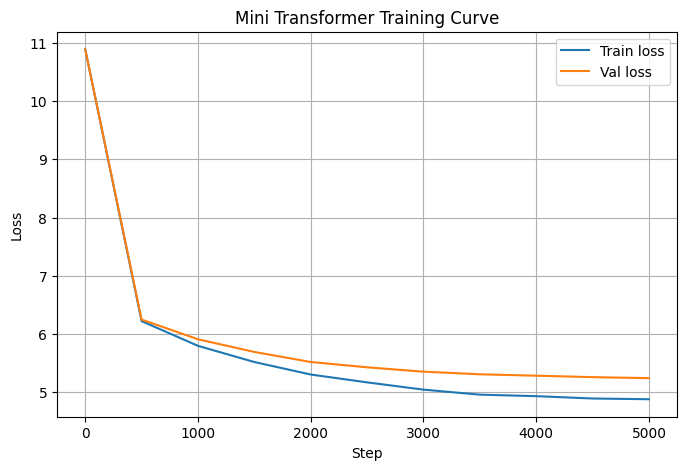

In [30]:
# CELL 16 — Plot training/validation loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(steps, train_losses, label="Train loss")
plt.plot(steps, val_losses, label="Val loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Mini Transformer Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# CELL 17 — Text generation (temperature + top-k + top-p)

model.eval()
with torch.no_grad():
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated = model.generate(
        context,
        max_new_tokens=GENERATE_TOKENS,
        temperature=TEMPERATURE,
        top_k=TOP_K,
        top_p=TOP_P
    )[0].tolist()

print(f"Generation settings → temperature={TEMPERATURE}, top_k={TOP_K}, top_p={TOP_P}\n")
print(decode(generated))

Generation settings → temperature=0.9, top_k=40, top_p=0.9

! The “the first thing I’m doing this,” and then I’m going to get around.

I don’t know the truth I’ve been doing so far as I wanted to do a few days. I think I’ve seen the kind of concern. It’s my mind. And my life is to me.

You’ve gotten that much of the world, and then it’s really the best for my life. I am sorry to say that I’m like I know if I was doing it. I’m all the last time, I can see it. I’m not doing it. That’s because I’m doing it. I think I’m not going to talk to me.

I’m not trying to get a big deal with the world. I think it’s a little bit more important to come from my life. I think they are going to see this. That’s a little bit. I’m able to give the thing to put the best of life. And I’m sure what we have to be in order to start in that.

It’s my ability to get some kind of things. I was happy to go to it. The idea is that I will be better on the process. I’ve been taking my time and I have to try to build 

In [32]:
# CELL 18 — Perplexity on restored best checkpoint

losses = estimate_loss()
train_ppl = math.exp(losses["train"])
val_ppl = math.exp(losses["val"])

print(f"Best checkpoint step: {best_iter}")
print(f"Best validation loss recorded during training: {best_val_loss:.4f}")
print(f"Train loss: {losses['train']:.4f}")
print(f"Val loss:   {losses['val']:.4f}")
print(f"Train perplexity: {train_ppl:.2f}")
print(f"Val perplexity:   {val_ppl:.2f}")

Best checkpoint step: 4999
Best validation loss recorded during training: 5.2422
Train loss: 4.8780
Val loss:   5.2579
Train perplexity: 131.36
Val perplexity:   192.08


In [33]:
# CELL 19 — Simple generation quality check

model.eval()
with torch.no_grad():
    context = torch.zeros((1, 1), dtype=torch.long, device=device)
    generated_ids = model.generate(
        context,
        max_new_tokens=GENERATE_TOKENS,
        temperature=TEMPERATURE,
        top_k=TOP_K,
        top_p=TOP_P      # was missing
    )[0].tolist()

generated_text = decode(generated_ids)

print("=== Generation Quality Check ===")
print(f"Generated length:    {len(generated_text)} characters")
print(f"Unique tokens used:  {len(set(generated_ids))}")   # tokens not chars
print(f"Generation settings: temperature={TEMPERATURE}, top_k={TOP_K}, top_p={TOP_P}")

current_losses = estimate_loss()
current_val_ppl = math.exp(current_losses["val"])
print(f"Model val perplexity: {current_val_ppl:.2f}  (lower = more predictable/coherent output)")

print("\n=== Sample Output ===\n")
print(generated_text)

=== Generation Quality Check ===
Generated length:    1684 characters
Unique tokens used:  141
Generation settings: temperature=0.9, top_k=40, top_p=0.9
Model val perplexity: 189.55  (lower = more predictable/coherent output)

=== Sample Output ===

!

I will be the next day in my car and it will be very hard to make this good time for this. I’m not going to know what I’m looking at the time to watch. I’m going to get some money, I have that. I’m not going to work on my hands and the whole game will be a very different time. I’m looking at this time, and I’ll see that I think of my way I’m going to be able to get myself so I could take it back on a minute. It’s very difficult to do that, but I’m not going to do with a lot of a team. I’m sorry, and I’m going to do it to be a big thing but I’ve been trying to put that time I’d get a little old guy that is going to have to have it to be. I’ve been to be able to do it out and the things you can’t play the end of the top. If you want to be 